## This just tests the non-dimensionalized direct integration of the SDE for x(t)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# Physical Constants and Parameters
M = 1.0
M_output = .01
w_0 = 1.0 
w_0_output = w_0
# Natural frequency (rad/s)
     # Driving frequency (rad/s), near 2*w_0 for w_p resonance
period = 2*jnp.pi/w_0
F_p = 0.05      # Amplitude of the w_p driving
Qual = 100.0
Qual_output = 10000.0
GAMMA = w_0/(2*Qual)
gamma = .003          # Nonlinearity coefficient (Duffing term)

k_13 = 1e-3
k_23 = k_13

w_p = 2*(w_0) # 2*w_0 + 2*k_13/M

k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = .2             # Temperature (K)
    # Noise strength
    
noise_strength =  jnp.sqrt(4*w_0*T/(2*Qual*M))  
noise_strength_output =  jnp.sqrt(4*w_0_output*T/(2*Qual_output*M_output))  

# Simulation Parameters
t0 = 0.0  
num_periods = 30000//2# Start time
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)

# Initial Conditions
y0 = jnp.zeros(6)



CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
# K_matrix = jnp.zeros((3, 3))

# # Fill in stiffness terms
# K_matrix = K_matrix.at[0,0].set(M*w_0**2 + k_13)    # x1 terms
# K_matrix = K_matrix.at[0,2].set(-k_13)
# K_matrix = K_matrix.at[1,1].set(M*w_0**2 + k_23)    # x2 terms
# K_matrix = K_matrix.at[1,2].set(-k_23)
# K_matrix = K_matrix.at[2,0].set(-k_13)              # x3 terms
# K_matrix = K_matrix.at[2,1].set(-k_23)
# K_matrix = K_matrix.at[2,2].set(M*w_0**2 +k_13 + k_23)

# # ... existing K_matrix setup ...

# # Get eigenvalues and eigenvectors, then sort them
# eigenvals, eigenvecs = jnp.linalg.eig(K_matrix)
# idx = jnp.argsort(jnp.real(eigenvals))  # Sort based on real part
# sorted_eigenvals = eigenvals[idx]
# sorted_eigenvecs = eigenvecs[:, idx]

# # Return sorted results
# sorted_eigenvals, sorted_eigenvecs

# w_p = 2*sorted_eigenvals[0].real

In [4]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    x1, v1, x2, v2, x3, v3 = state
    dx1dt = v1
    dv1dt =  -w_0/(2*Qual*M) * v1 -  (w_0**2 -F_p/M * jnp.cos(w_p * t)) * x1 - gamma/M * x1**3 - k_13/M * (x1 - x3)
    dx2dt = v2
    dv2dt =  -w_0/(2*Qual*M) * v2 -  (w_0**2 -F_p/M * jnp.cos(w_p * t)) * x2 - gamma/M * x2**3 - k_23/M * (x2 - x3)
    dx3dt = v3
    dv3dt =  -w_0_output/(2*Qual_output*M_output) * v3 -  (w_0_output**2 -0.*F_p/M_output * jnp.cos(w_p * t)) * x3 + k_13/M_output * (x1 - x3) + k_23/M_output * (x2 - x3)
    return jnp.array([dx1dt, dv1dt, dx2dt, dv2dt, dx3dt, dv3dt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion 
    """

    noise_matrix = jnp.zeros((6, 6))
    noise_matrix = noise_matrix.at[1, 1].set(noise_strength)
    noise_matrix = noise_matrix.at[3, 3].set(noise_strength)
    noise_matrix = noise_matrix.at[5, 5].set(noise_strength_output)
    return noise_matrix

In [5]:
w_shape = (6,)  # state is (x1, p1)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)
terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
saveat = diffrax.SaveAt(ts=ts_dim)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=1000000000,
    # stepsize_controller=PIDController(rtol=rtol, atol=atol),
)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

In [6]:

from scipy.signal import hilbert
import numpy as np

x1 = solution_x.ys[:, 0]
x2 = solution_x.ys[:, 2]
x3 = solution_x.ys[:, 4]

# Extract phases using Hilbert transform
analytic_signal_x1 = hilbert(x1)
analytic_signal_x2 = hilbert(x2)
analytic_signal_x3 = hilbert(x3)

# Calculate phase difference between x₁ and x₂
phase_diff = np.angle(analytic_signal_x1) - np.angle(analytic_signal_x2)
# Wrap to [-π, π]
phase_diff = np.mod(phase_diff + np.pi, 2 * np.pi) - np.pi

# # Unwrap the phase difference to remove 2π jumps
# phase_diff = np.unwrap(phase_diff)

# ... rest of the code ...

# Calculate envelope of x₃
envelope = np.abs(analytic_signal_x3)



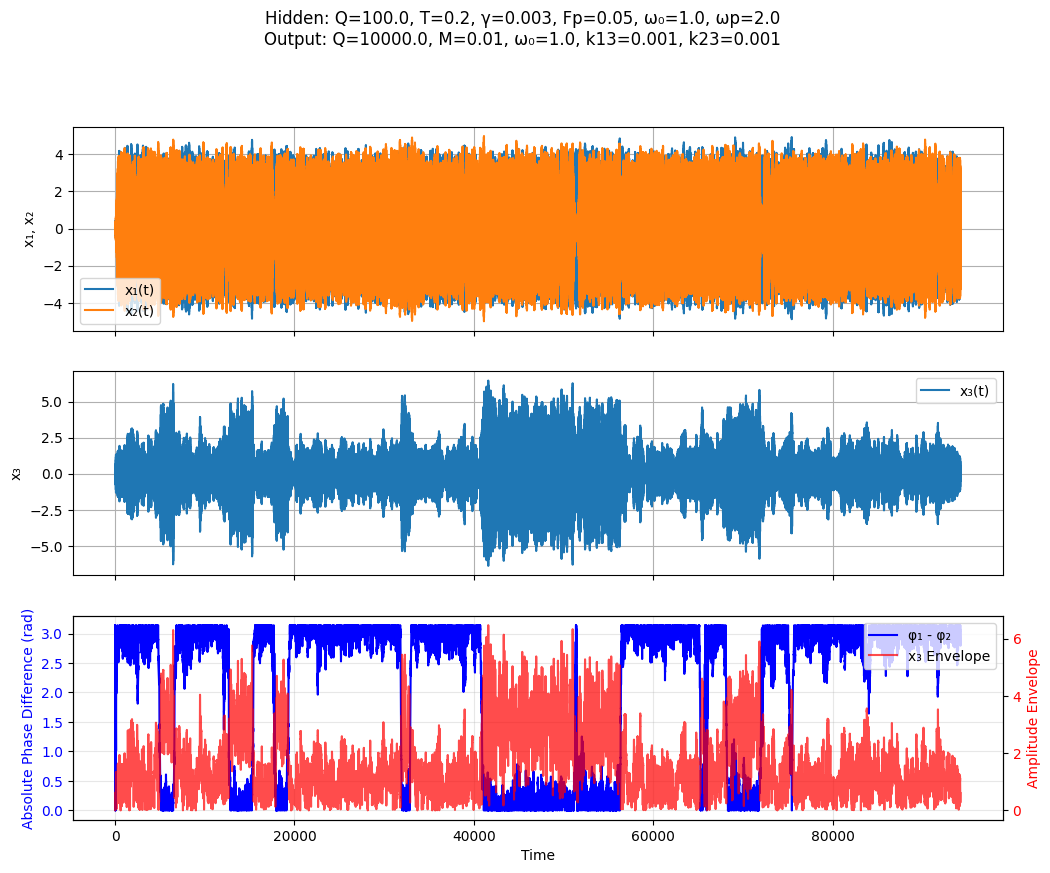

In [7]:
# Define start and end times as fractions of total time
start_frac = 0.0  # Start at beginning
end_frac = 1    # Show first 20%

# Calculate indices for the time window
start_idx = int(len(ts_dim) * start_frac)
end_idx = int(len(ts_dim) * end_frac)


# Create a 3x1 figure
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

title = (f'Hidden: Q={Qual}, T={T}, γ={gamma}, Fp={F_p}, ω₀={w_0}, ωp={w_p}\n'
         f'Output: Q={Qual_output}, M={M_output}, ω₀={w_0_output}, k13={k_13}, k23={k_23}')

# ... rest of plotting code ...
fig.suptitle(title, y=1.01)  # y=1.02 moves the title slightly above the figure

# First subplot: x1 and x2
ax1.plot(ts_dim[start_idx:end_idx], solution_x.ys[start_idx:end_idx, 0], label='x₁(t)')
ax1.plot(ts_dim[start_idx:end_idx], solution_x.ys[start_idx:end_idx, 2], label='x₂(t)')
ax1.set_ylabel('x₁, x₂')
ax1.grid(True)
ax1.legend()

# Second subplot: x3
ax2.plot(ts_dim[start_idx:end_idx], solution_x.ys[start_idx:end_idx, 4], label='x₃(t)')
ax2.set_ylabel('x₃')
ax2.grid(True)
ax2.legend()

# Third subplot: Phase difference and envelope
ax3_twin = ax3.twinx()

# Plot phase difference
l1 = ax3.plot(ts_dim[start_idx:end_idx], 
              jnp.abs(phase_diff[start_idx:end_idx]), 
              label='φ₁ - φ₂', color='blue')
ax3.set_ylabel('Absolute Phase Difference (rad)', color='blue')
ax3.tick_params(axis='y', labelcolor='blue')

# Plot envelope
l2 = ax3_twin.plot(ts_dim[start_idx:end_idx], 
                   envelope[start_idx:end_idx],
                   label='x₃ Envelope', color='red', alpha=0.7)
ax3_twin.set_ylabel('Amplitude Envelope', color='red')
ax3_twin.tick_params(axis='y', labelcolor='red')

# Add legend to third subplot
lns = l1 + l2
labs = [l.get_label() for l in lns]
ax3.legend(lns, labs, loc='upper right')

ax3.grid(True, alpha=0.3)
ax3.set_xlabel('Time')



# Create a safe filename by replacing unsafe characters
safe_title = f"pbit_Q{Qual}_T{T}_g{gamma}_Fp{F_p}_w0{w_0}_wp{w_p}_Qins{Qual_output}_Mins{M_output}_w0ins{w_0_output}_k13{k_13}_k23{k_23}"
safe_title = safe_title.replace('.', 'p').replace('-', 'm')  # Replace decimals and minus signs
save_path = f"../out/p-bit_new/{safe_title}.png"  # Add .png extension

# Save and show the figure
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()